# **FINAL MODEL: Multimodal Integration - Late Fusion (EfficientNetB1 + Metadata MLP)**

**Objective:**
Inclusion of **clinical metadata**
- **Age**
- **Sex**
- **Atomic location** of the lesion
<br>

**Methodology:**
| Variable | Strategy | NA Treatment |
|----------|-----------|--------------------|
| Age | Normalization (min-max) | Imputation by median |
| Sex | One-hot encoding | Category "unknown" |
| Location | One-hot encoding (15 sítios) | Category "unknown" |

### Imports

In [50]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize, MinMaxScaler

# Add project root to sys.path so local utils are importable
sys.path.insert(0, os.path.abspath(".."))
from utils.utils_preproc import create_dl_splits, format_center_crop_tf
from utils.utils_model import get_callbacks, plot_history


### **Data** Configuration

In [51]:
if os.getcwd().endswith('models'):
    os.chdir('..')

In [52]:
# Image directories
BASE_PATH  = "./data"
AUG_IMG_DIR = os.path.join(BASE_PATH, "HAM10000_augmented")
CLEANED_IMG_DIR = os.path.join(BASE_PATH, "HAM10000_cleaned/train")
VAL_IMG_DIRS = [os.path.join(BASE_PATH, "HAM10000_cleaned/val")]
TEST_IMG_DIRS = [os.path.join(BASE_PATH, "HAM10000_cleaned/test")]

# Metadata CSVs — splits already done upstream
AUG_META_PATH  = os.path.join(BASE_PATH, "augmented_metadata.csv")  # train 
VAL_META_PATH  = os.path.join(BASE_PATH, "val_split.csv")
TEST_META_PATH = os.path.join(BASE_PATH, "test_split.csv")

In [53]:
LABEL_PATH = os.path.join(BASE_PATH, "..", "label2idx.json")

In [54]:
# Load the fixed metadata
df = pd.read_csv(AUG_META_PATH)

In [55]:
# We need a final 'model_path' column that points to the actual file
# This handles both original images and the new AUG images automatically
def get_final_path(row):
    if row['dataset'] == 'augmented':
        return os.path.join(AUG_IMG_DIR, f"{row['image_id']}.jpg")
    else:
        # This handles your original ISIC images
        return os.path.join(CLEANED_IMG_DIR, f"{row['image_id']}_cleaned.jpg")

df['final_path'] = df.apply(get_final_path, axis=1)

In [56]:
# Quick Sanity Check
print(f"Total samples: {len(df)}")
print(f"Samples with missing Age/Sex: {df[['age', 'sex']].isnull().sum().sum()}") # Should be 0!

Total samples: 12621
Samples with missing Age/Sex: 0


In [57]:
N_CLASSES  = 7
BATCH_SIZE = 32
IMG_SIZE   = 224

### **Data** Loading & Mapping

In [58]:
aug_df = pd.read_csv(AUG_META_PATH) #augmented_metadata
val_df  = pd.read_csv(VAL_META_PATH)
test_df = pd.read_csv(TEST_META_PATH)

In [59]:
# Label encoding (shared across all splits)
with open(LABEL_PATH) as fh:
    label2idx = json.load(fh)
idx2label = {v: k for k, v in label2idx.items()}

In [60]:
# 3.2  TRAIN  (augmented data)
# We rename it to 'final_path' to be consistent across all splits
aug_df = aug_df.rename(columns={'processed_path': 'final_path'})
print(f"Train (augmented) images linked: {len(aug_df)}")


Train (augmented) images linked: 12621


In [61]:
# 3. Fix Val & Test Paths (mapping to the _cleaned.jpg files)

clean_img_map = {}

# We look in the specific 'cleaned' directories for val and test
# Note: Ensure these paths match your local folder structure exactly
for d in [os.path.join(BASE_PATH, "HAM10000_cleaned/val"), 
          os.path.join(BASE_PATH, "HAM10000_cleaned/test")]:
    if os.path.exists(d):
        for f in os.listdir(d):
            if f.lower().endswith(".jpg"):
                # We store the mapping using the ID WITHOUT the suffix
                # Example: 'ISIC_0024313_cleaned' becomes 'ISIC_0024313'
                img_id_key = f.replace("_cleaned.jpg", "")
                clean_img_map[img_id_key] = os.path.join(d, f)


for split_df, name in [(val_df, "Val"), (test_df, "Test")]:
    # Match the CSV 'image_id' to our map
    split_df["final_path"] = split_df["image_id"].map(clean_img_map)
    
    # Check how many were lost
    missing = split_df["image_path"].isna().sum()
    if missing > 0:
        print(f"Warning: {missing} images not found in {name} folders.")
    
    split_df.dropna(subset=["image_path"], inplace=True)
    split_df.reset_index(drop=True, inplace=True)
    
    if "dx_encoded" not in split_df.columns:
        split_df["dx_encoded"] = split_df["dx"].map(label2idx)
        
    print(f"{name} linked: {len(split_df)} images")

Val linked: 1152 images
Test linked: 1126 images


## Metadata preprocessing

In [62]:
# 1. Combine to ensure One-Hot Encoding creates identical columns for all splits
# This prevents "dimension mismatch" errors if a body location is in Val but not Train
all_data = pd.concat([aug_df, val_df, test_df], keys=['train', 'val', 'test'], sort=False)

# 2. One-Hot Encode clinical features
all_data = pd.get_dummies(all_data, columns=['sex', 'localization'])

# 3. Normalize Age (filling NaNs with median to prevent NaN loss)
scaler = MinMaxScaler()
all_data['age_norm'] = scaler.fit_transform(all_data[['age']].fillna(all_data['age'].median()))

# 4. Split back into dataframes
train_df = all_data.xs('train')
val_df   = all_data.xs('val')
test_df  = all_data.xs('test')

# 5. Define the vector list (this replaces your old META_COLS logic)
sex_cols = [c for c in train_df.columns if c.startswith("sex_")]
loc_cols = [c for c in train_df.columns if c.startswith("localization_")]
META_COLS = ["age_norm"] + sex_cols + loc_cols
META_DIM  = len(META_COLS)

# 6. CRITICAL: Create the 'meta_vector' column that the make_ds function needs
for df_split in [train_df, val_df, test_df]:
    df_split['meta_vector'] = df_split[META_COLS].values.tolist()
print(f"MLP Input Dimension: {META_DIM} features")
print(f"Features: {META_COLS}")

MLP Input Dimension: 19 features
Features: ['age_norm', 'sex_female', 'sex_male', 'sex_unknown', 'localization_abdomen', 'localization_acral', 'localization_back', 'localization_chest', 'localization_ear', 'localization_face', 'localization_foot', 'localization_genital', 'localization_hand', 'localization_lower extremity', 'localization_neck', 'localization_scalp', 'localization_trunk', 'localization_unknown', 'localization_upper extremity']


Clean and encode the clinical features (Age, Sex, Localization) into a fixed-length vector before the split.

In [63]:
# Identify feature columns from aug_df
sex_ohe_cols = sorted([c for c in aug_df.columns if c.startswith("sex_")])
loc_ohe_cols = sorted([c for c in aug_df.columns if c.startswith("localization_")])
META_COLS    = ["age_norm"] + sex_ohe_cols + loc_ohe_cols
META_DIM     = len(META_COLS)
print(f"MLP input dim: {META_DIM}  →  {META_COLS}")

MLP input dim: 1  →  ['age_norm']


In [64]:
# Fill missing age_norm in augmented rows with train mean
age_mean = aug_df["age"].mean()
aug_df["age_norm"] = aug_df["age"].fillna(age_mean)

C:\Users\maria\AppData\Local\Temp\ipykernel_13636\549351408.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(age_by_dx, labels=classes_order) # Use ax1


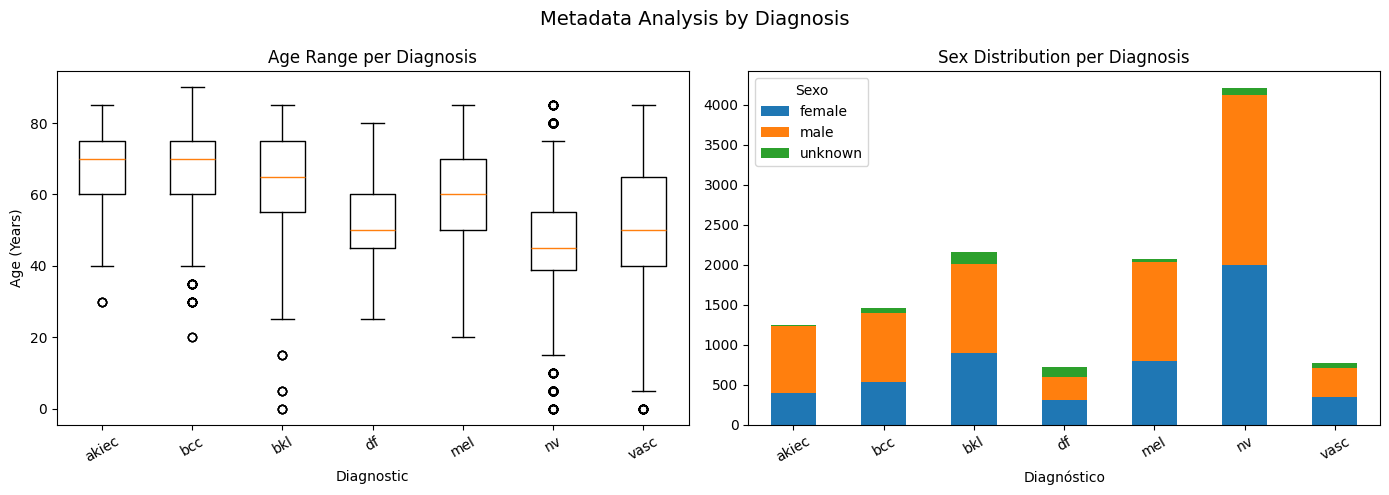

In [ ]:
# ── FIX: DIRECT UNPACKING ──────────────────────────────────────────────────
df_to_plot = aug_df 

# We name them ax1 and ax2 directly here
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Metadata Analysis by Diagnosis", fontsize=14)

# 1. Age by diagnosis
classes_order = sorted(df_to_plot["dx"].unique())
age_by_dx = [df_to_plot[df_to_plot["dx"] == c]["age"].dropna().values for c in classes_order]

ax1.boxplot(age_by_dx, labels=classes_order) # Use ax1
ax1.set_title("Age Range per Diagnosis")
ax1.set_xlabel("Diagnostic")
ax1.set_ylabel("Age (Years)")
ax1.tick_params(axis='x', rotation=30)

# 2. Sex distribution
sex_dx = df_to_plot.groupby(["dx", "sex"]).size().unstack(fill_value=0)

# Tell pandas to use ax2
sex_dx.plot(kind="bar", ax=ax2, stacked=True) 

ax2.set_title("Sex Distribution per Diagnosis")
ax2.set_xlabel("Diagnostic")
ax2.tick_params(axis='x', rotation=30)
ax2.legend(title="Sex")

plt.tight_layout()
plt.show()

## 4. Multimodal Data Pipeline

In [ ]:
BATCH_SIZE = 32

def load_multimodal_item(img_path, meta_vec, label):
    # Image Branch
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)
    img = format_center_crop_tf(img) 
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    
    # Returning a dictionary matching input names in build_late_fusion_model
    return {"image_input": img, "meta_input": meta_vec}, label

def make_ds(df_split, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df_split["final_path"].values,
        np.stack(df_split["meta_vector"].values),
        df_split["dx_encoded"].values.astype(np.int32)
    ))
    if shuffle: ds = ds.shuffle(2000)
    return ds.map(load_multimodal_item).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_df, shuffle=True)
val_ds   = make_ds(val_df, shuffle=False)
test_ds  = make_ds(test_df, shuffle=False)

## 5. Architecture Late Fusion: EfficientNetB1 + Metadata MLP 

This builds the two branches and concatenates them into the final classification head.

In [23]:
def build_late_fusion_model(meta_dim, n_classes=7):
    # Image Branch
    img_input = keras.Input(shape=(224, 224, 3), name="image_input")
    backbone = keras.applications.EfficientNetB0(include_top=False, weights="imagenet", input_tensor=img_input)
    backbone.trainable = False  # Frozen for Phase 1

    x = keras.layers.GlobalAveragePooling2D()(backbone.output)
    x = keras.layers.Dense(256, activation="relu")(x)
    img_features = keras.layers.Dropout(0.4)(x)

    # Metadata Branch
    meta_input = keras.Input(shape=(meta_dim,), name="meta_input")
    m = keras.layers.Dense(64, activation="relu")(meta_input)
    m = keras.layers.BatchNormalization()(m)
    meta_features = keras.layers.Dense(32, activation="relu")(m)

    # Late Fusion
    combined = keras.layers.Concatenate()([img_features, meta_features])
    z = keras.layers.Dense(128, activation="relu")(combined)
    out = keras.layers.Dense(n_classes, name="logits")(z)

    return keras.Model(inputs=[img_input, meta_input], outputs=out)

model = build_late_fusion_model(META_DIM)
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

## 6. Phase 1: Training the Fusion Head (Backbone Frozen)

In [ ]:
# Callbacks from your utils
callbacks = get_callbacks(model_name="late_fusion_phase1")

# Phase 1 Training
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

plot_history(history_phase1)

## 7. Phase 2: Fine-Tuning (Unfrozen)

In [ ]:
# Unfreeze the backbone
for layer in model.layers:
    if "efficientnet" in layer.name:
        layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-5), # Very low learning rate
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

callbacks_ft = get_callbacks(model_name="late_fusion_finetuned")

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_ft
)

## 8. Final Evaluation & Confusion Matrix

In [ ]:
# Predict
y_pred_logits = model.predict(test_ds)
y_pred = np.argmax(y_pred_logits, axis=1)
y_true = test_df["dx_encoded"].values

# Classification Report
print(classification_report(y_true, y_pred, target_names=list(label2idx.keys())))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label2idx.keys(), yticklabels=label2idx.keys())
plt.title("Confusion Matrix - Multimodal Late Fusion")
plt.show()

## 9. Ablation Study: What is the clinical data worth?
To see if the metadata actually contributes to the model, we run the test set again but "blind" the model by passing zero vectors as metadata.

In [ ]:
# Create a "Blind" metadata set (all zeros)
test_meta_zeros = np.zeros_like(np.stack(test_df["meta_vector"].values))

blind_ds = tf.data.Dataset.from_tensor_slices((
    {"image_input": test_df["image_path"].values, "meta_input": test_meta_zeros},
    test_df["dx_encoded"].values
)).map(lambda x, y: ({"image_input": load_multimodal_item(x["image_input"], x["meta_input"], y)[0]["image_input"], 
                      "meta_input": x["meta_input"]}, y)).batch(BATCH_SIZE)

# Evaluate Blind vs Multimodal
loss_m, acc_m = model.evaluate(test_ds)
loss_b, acc_b = model.evaluate(blind_ds)

print(f"Accuracy with Metadata: {acc_m:.4f}")
print(f"Accuracy without Metadata (Blind): {acc_b:.4f}")
print(f"Clinical Lift: {acc_m - acc_b:.4f}")